## Genomics

Leukemia is a cancer of blood-generating tissues. Over 475,000 Americans have Leukemia or are in remission from it. It accounts for 3.3% of all new cancer cases and 3.8% of cancer deaths, with an estimated 66,890 new cases and 23,540 deaths in the U.S. in 2025.

There are two major leukemia families: Acute Lymphoblastic Leukemia (ALLB and ALLT, or ALL), which is cancer of immature lymphoid cells, and Acute Myeloid Leukemia (AML), which is cancer of cancer of immature myeloid cells.

Golub et al. (*Science*, 1999) popularized a dataset including about 7000 genes from 72 patients. The goal is to use genomics data to predict which patients are at risk of ALL versus AML, because the distinction is critical for timely and effective treatment.

1. Load the `golub.csv` dataset. Relabel all instances of ALLB and ALLT as 0, and all instances of ALL as 1. This is the target variable. 



In [2]:

import pandas as pd


df = pd.read_csv('data/golub.csv')


mapping = {
    'ALLB': 0, 'allB': 0,
    'ALLT': 0, 'allT': 0,
    'ALL': 1,  'all': 1,
    'AML': 1,  'aml': 1  
}

df['cancer'] = df['cancer'].replace(mapping)

print(df['cancer'].value_counts())



cancer
0    47
1    25
Name: count, dtype: int64


/var/folders/89/vy1sctd5199dh7fb1_5765v00000gn/T/ipykernel_22590/192502359.py:14: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['cancer'] = df['cancer'].replace(mapping)




2. Use Linear Regression of the target variable on all of the genes provided. What is your mean squared error? Make a kernel density plot of your residuals, and a scatter plot comparing predicted and actual outcomes. 



Mean Squared Error: 1.649109613713977e-30


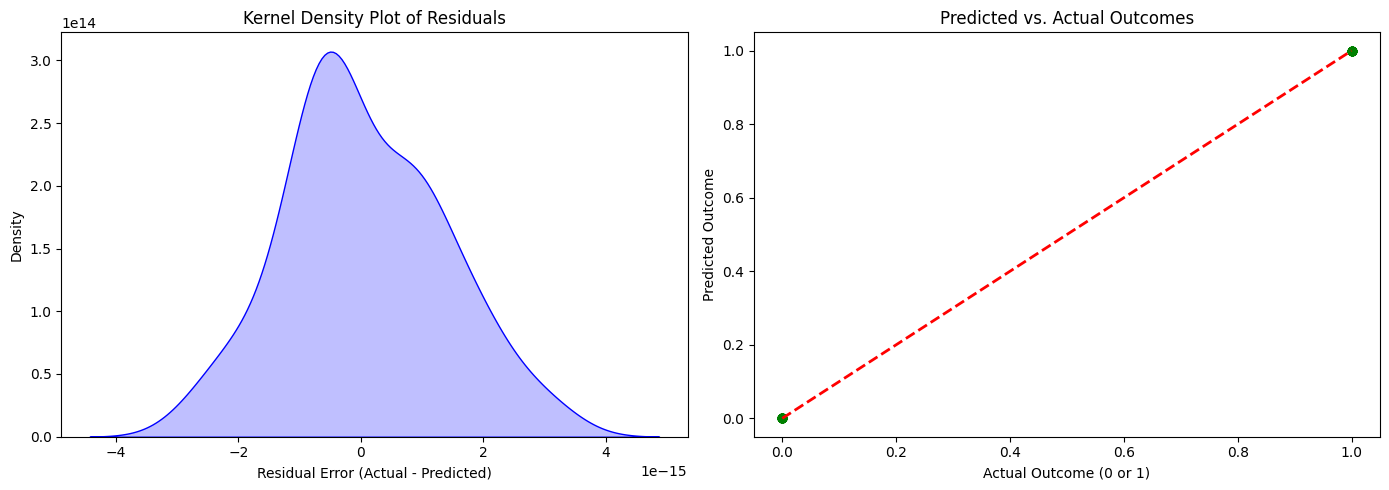

In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Isolate the genes (Features / X) and target variable (y)
metadata_columns = ['Samples', 'BM.PB', 'Gender', 'Source', 'tissue.mf', 'cancer']
X = df.drop(columns=metadata_columns)  # Drop the non-gene columns to keep only the numeric genes
y = df['cancer']                       # Set your already-relabeled target variable

# 2. Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X, y)

# 3. Make predictions and compute the Mean Squared Error (MSE)
predictions = model.predict(X)
mse = mean_squared_error(y, predictions)
print(f"Mean Squared Error: {mse}")

# 4. Calculate the residuals (errors)
residuals = y - predictions

# 5. Create the visualizations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))  # Create a side-by-side plot layout

# Graph A: Kernel Density Plot of Residuals
sns.kdeplot(residuals, ax=axes[0], fill=True, color="blue")
axes[0].set_title('Kernel Density Plot of Residuals')
axes[0].set_xlabel('Residual Error (Actual - Predicted)')

# Graph B: Scatter Plot of Predicted vs. Actual Outcomes
axes[1].scatter(y, predictions, alpha=0.7, color="green")
axes[1].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2) # Red 1-to-1 reference line
axes[1].set_title('Predicted vs. Actual Outcomes')
axes[1].set_xlabel('Actual Outcome (0 or 1)')
axes[1].set_ylabel('Predicted Outcome')

plt.tight_layout() # Ensures everything is spaced out cleanly
plt.show()




3. Use cross validation to compute the mean squared error of the linear model. Discuss your results from the perspective of the bias variance trade-off.

4. Use the cross validated LASSO to select a set of highly predictive genes. Which set of genes is selected? How many genes are discarded from the model? Make a scatterplot of your predictions versus the actual values. 

5. Make a plot that shows the cross validated MSE as $alpha$ varies. For what values of $\alpha$ is the LASSO underfitting? Overfitting? What is the optimal penality hyperparameter that minimizes expected MSE?

6. Explain why linear regression performs perfectly on the training set, but the LASSO provides better predictions overall.

7. Why do regularization methods lend themselves to scenarios like precision health? 

8. What are the risks of applying methods like the Lasso to precision health questions, where interventions will then be taken to optimize patient health?